## Régressions
Analyse des régressions linéaire et logistique, inspirée de `reg lin.py`.

In [13]:
# Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression

sns.set(style="whitegrid")

# Charger le dataset (même fichier que dans le projet)
df = pd.read_csv("../dataset/student-mat.csv")

# df = pd.read_csv("../dataset/student-por.csv")

**Préparation : variables explicatives, encodage et standardisation**

In [6]:
features = [
    "Medu",
    "Fedu",
    "failures",
    "sex",
    "internet",
    "famsup",
    "studytime",
    "Dalc",
    "Walc",
    "goout"
]

df_encoded = df.copy()
binary_map = {
    "yes": 1,
    "no": 0,
    "F": 0,
    "M": 1
}

for col in ["sex", "internet", "famsup"]:
    df_encoded[col] = df_encoded[col].map(binary_map)

# Standardisation
X_base = df_encoded[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

print("Données préparées — shape:", df.shape)

Données préparées — shape: (395, 33)


**Fonction d'évaluation (classification)**

In [7]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print("" + "="*60)
    print(name)
    print("="*60)

    print(f"Accuracy           : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Balanced Accuracy  : {balanced_accuracy_score(y_test, y_pred):.3f}")
    print(f"F1-score           : {f1_score(y_test, y_pred):.3f}")

    if y_prob is not None:
        print(f"ROC AUC            : {roc_auc_score(y_test, y_prob):.3f}")

    print("Classification report:")
    print(classification_report(y_test, y_pred))

    return model

**1) Régression logistique — prédiction de `higher`**

In [8]:
y = df_encoded['higher'].map(binary_map)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

logreg = LogisticRegression(max_iter=500)

evaluate_classifier(logreg, X_train, X_test, y_train, y_test, "Regression logistique — higher")

Regression logistique — higher
Accuracy           : 0.950
Balanced Accuracy  : 0.500
F1-score           : 0.974
ROC AUC            : 0.822
Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.95      1.00      0.97       113

    accuracy                           0.95       119
   macro avg       0.47      0.50      0.49       119
weighted avg       0.90      0.95      0.93       119



c:\Users\HKHD\anaconda3\envs\sy09\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HKHD\anaconda3\envs\sy09\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HKHD\anaconda3\envs\sy09\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

    Variable  Coefficient  AbsCoeff
6  studytime     0.703634  0.703634
3        sex    -0.599608  0.599608
2   failures    -0.484745  0.484745
1       Fedu     0.442889  0.442889
0       Medu     0.348329  0.348329
9      goout     0.346065  0.346065
8       Walc     0.198772  0.198772
7       Dalc    -0.141118  0.141118
4   internet    -0.123593  0.123593
5     famsup     0.062083  0.062083


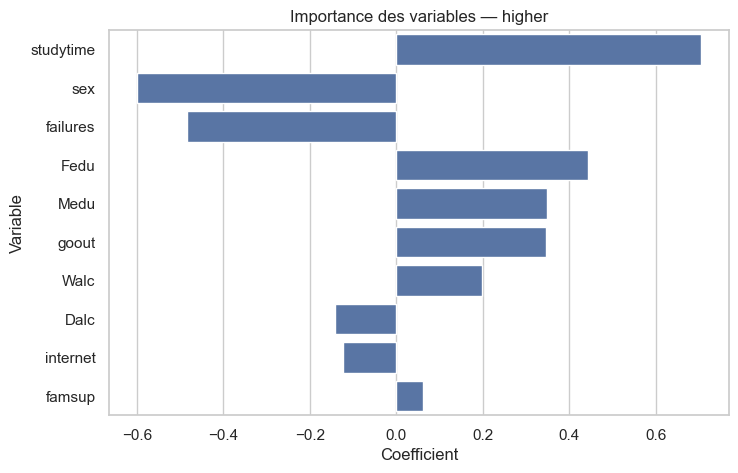

In [9]:
# Coefficients et visualisation
coeffs = pd.DataFrame({
    'Variable': features,
    'Coefficient': logreg.coef_[0]
})
coeffs['AbsCoeff'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='AbsCoeff', ascending=False)

print(coeffs)

plt.figure(figsize=(8,5))
sns.barplot(data=coeffs, x='Coefficient', y='Variable')
plt.title('Importance des variables — higher')
plt.show()

**2) Régression linéaire — prédiction de `G3`**

R2    : 0.144
RMSE  : 4.339
    Variable  Coefficient  AbsCoeff
2   failures    -1.556128  1.556128
0       Medu     0.810727  0.810727
9      goout    -0.659607  0.659607
8       Walc     0.458933  0.458933
5     famsup    -0.442372  0.442372
1       Fedu    -0.399455  0.399455
6  studytime     0.369448  0.369448
4   internet     0.360992  0.360992
3        sex     0.291155  0.291155
7       Dalc    -0.241125  0.241125


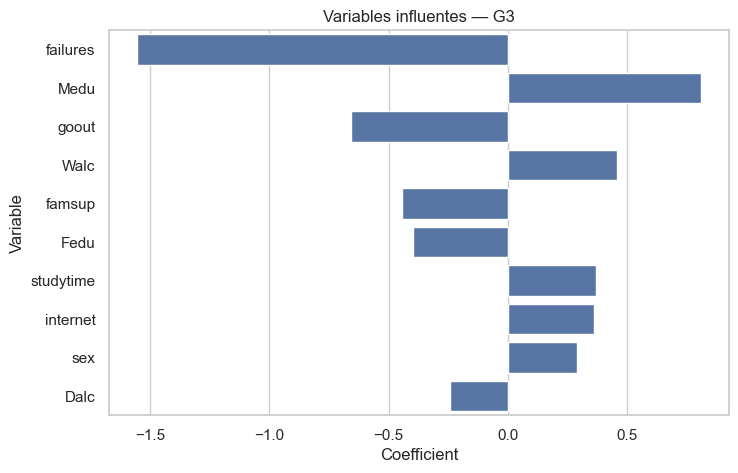

In [10]:
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

print(f'R2    : {r2_score(y_test, y_pred):.3f}')
print(f'RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')

coeffs_g3 = pd.DataFrame({
    'Variable': features,
    'Coefficient': linreg.coef_
})
coeffs_g3['AbsCoeff'] = coeffs_g3['Coefficient'].abs()
coeffs_g3 = coeffs_g3.sort_values(by='AbsCoeff', ascending=False)
print(coeffs_g3)

plt.figure(figsize=(8,5))
sns.barplot(data=coeffs_g3, x='Coefficient', y='Variable')
plt.title('Variables influentes — G3')
plt.show()

**3) Régression linéaire — prédiction des `absences`**

R2    : 0.144
RMSE  : 4.339
    Variable  Coefficient  AbsCoeff
2   failures    -1.556128  1.556128
0       Medu     0.810727  0.810727
9      goout    -0.659607  0.659607
8       Walc     0.458933  0.458933
5     famsup    -0.442372  0.442372
1       Fedu    -0.399455  0.399455
6  studytime     0.369448  0.369448
4   internet     0.360992  0.360992
3        sex     0.291155  0.291155
7       Dalc    -0.241125  0.241125


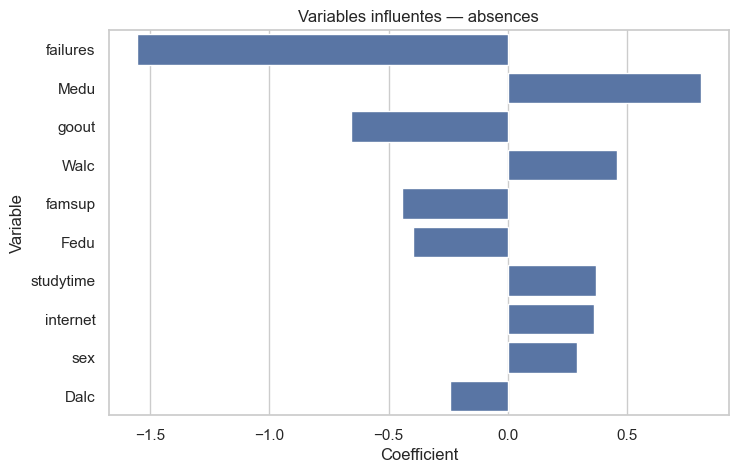

In [11]:
y = df['absences']
linreg_abs = LinearRegression()
linreg_abs.fit(X_train, y_train)  # réutilise X_train défini ci-dessus pour consistance
y_pred_abs = linreg_abs.predict(X_test)

print(f'R2    : {r2_score(y_test, y_pred_abs):.3f}')
print(f'RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred_abs)):.3f}')

coeffs_abs = pd.DataFrame({
    'Variable': features,
    'Coefficient': linreg_abs.coef_
})
coeffs_abs['AbsCoeff'] = coeffs_abs['Coefficient'].abs()
coeffs_abs = coeffs_abs.sort_values(by='AbsCoeff', ascending=False)
print(coeffs_abs)

plt.figure(figsize=(8,5))
sns.barplot(data=coeffs_abs, x='Coefficient', y='Variable')
plt.title('Variables influentes — absences')
plt.show()

---
Fin de l'analyse principale. je peux :
- ajouter l'ACP + KMeans comme dans `acp_kmeans.ipynb`,
- effectuer les régressions par cluster,
- exécuter les cellules et joindre les résultats.